In [1]:
import os

from IPython.display import display
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP

os.makedirs("tutorial_output/data", exist_ok=True)

# Create dataset
dataset = QSPRDataset.fromTableFile(
    filename="../../../../tutorials/tutorial_data/A2A_LIGANDS.tsv",
    store_dir="tutorial_output/data",
    name="MonitoringTutorialDataset",
    target_props=[{"name": "pchembl_value_Mean", "task": "SINGLECLASS", "th" : [6.5]}],
    random_state=42
)

In [2]:

# calculate compound features and split dataset into train and test
dataset.prepareDataset(
    split=RandomSplit(test_fraction=0.2, dataset=dataset),
    feature_calculators=[MorganFP(radius=3, nBits=2048)],
    recalculate_features=True,
)

dataset.getDF().head()

,SMILES,pchembl_value_Mean,Year,QSPRID,pchembl_value_Mean_original
QSPRID,,,,,
MonitoringTutorialDataset_0000,Cc1cc(C)n(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n...,True,2008.0,MonitoringTutorialDataset_0000,8.68
MonitoringTutorialDataset_0001,Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2nc3c(cc12...,False,2010.0,MonitoringTutorialDataset_0001,4.82
MonitoringTutorialDataset_0002,O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1,False,2009.0,MonitoringTutorialDataset_0002,5.65
MonitoringTutorialDataset_0003,CNC(=O)C12CC1C(n1cnc3c(NCc4cccc(Cl)c4)nc(C#CCC...,False,2009.0,MonitoringTutorialDataset_0003,5.45
MonitoringTutorialDataset_0004,CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(...,False,2019.0,MonitoringTutorialDataset_0004,5.20


In [6]:
model_sts = STFullyConnected(
        n_dim=dataset.X.shape[1],  # počet vstupních neuronů (počet deskriptorů)
        n_class=1,  # regresní úloha (1 výstup)
        gpus=[],
        device="cpu",
        batch_size=256,
        patience=20,
        tol=1e-4,
        neuron_layers=[200, 100],
        is_reg=False
    )
model_sts.fit(dataset.X, dataset.y)


(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=2048, out_features=200, bias=True)
     (1): Linear(in_features=200, out_features=100, bias=True)
     (2): Linear(in_features=100, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.25, inplace=False)
   (fc0): Linear(in_features=2048, out_features=256, bias=True)
   (fc1): Linear(in_features=256, out_features=128, bias=True)
   (fc3): Linear(in_features=128, out_features=1, bias=True)
   (criterion): BCELoss()
   (final_layer_activation): Sigmoid()
 ),
 0)

In [7]:

# Create model
from qsprpred.extra.gpu.models.dnn import DNNModel

os.makedirs("tutorial_output/models", exist_ok=True)
model = DNNModel(
    base_dir='tutorial_output/models',
    name='MonitoringTutorialModel',
    patience=3,
    tol=0.01,
    
)


In [8]:
model.loadEstimator(model_sts.get_params())

STFullyConnected(
  (layers): ModuleList(
    (0): Linear(in_features=2048, out_features=200, bias=True)
    (1): Linear(in_features=200, out_features=100, bias=True)
    (2): Linear(in_features=100, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.25, inplace=False)
  (fc0): Linear(in_features=2048, out_features=256, bias=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (criterion): BCELoss()
  (final_layer_activation): Sigmoid()
)

In [20]:
from qsprpred.data.descriptors.fingerprints import MaccsFP
# model.loadEstimator(model_sts)
# dataset.addDescriptors([MaccsFP()])

In [9]:
display(dataset.X.head())
print(dataset.y.sum() , '/', len(dataset.y))
print(dataset.y_ind.sum() , '/', len(dataset.y_ind))

,MorganFP_MorganFP_0,MorganFP_MorganFP_1,MorganFP_MorganFP_2,MorganFP_MorganFP_3,MorganFP_MorganFP_4,MorganFP_MorganFP_5,MorganFP_MorganFP_6,MorganFP_MorganFP_7,MorganFP_MorganFP_8,MorganFP_MorganFP_9,...,MorganFP_MorganFP_2038,MorganFP_MorganFP_2039,MorganFP_MorganFP_2040,MorganFP_MorganFP_2041,MorganFP_MorganFP_2042,MorganFP_MorganFP_2043,MorganFP_MorganFP_2044,MorganFP_MorganFP_2045,MorganFP_MorganFP_2046,MorganFP_MorganFP_2047
QSPRID,,,,,,,,,,,,,,,,,,,,,
MonitoringTutorialDataset_0221,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
MonitoringTutorialDataset_3644,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
MonitoringTutorialDataset_2459,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
MonitoringTutorialDataset_1315,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
MonitoringTutorialDataset_1017,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,False,False


pchembl_value_Mean    2002
dtype: int64 / 3265
pchembl_value_Mean    493
dtype: int64 / 817


In [10]:
model.fit(dataset.X, dataset.y, estimator=model_sts)

STFullyConnected(
  (layers): ModuleList(
    (0): Linear(in_features=2048, out_features=200, bias=True)
    (1): Linear(in_features=200, out_features=100, bias=True)
    (2): Linear(in_features=100, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.25, inplace=False)
  (fc0): Linear(in_features=2048, out_features=256, bias=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (criterion): BCELoss()
  (final_layer_activation): Sigmoid()
)

In [11]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
print(accuracy_score(model.predict(dataset.X_ind), dataset.y_ind))
print(f1_score(model.predict(dataset.X_ind), dataset.y_ind))

0.6034271725826194
0.7526717557251908


In [14]:
from qsprpred.models import GridSearchOptimization
from qsprpred.models import TestSetAssessor, CrossValAssessor

# Define the search space
search_space = {"lr": [1e-4, 1e-3, ], "neuron_layers": [[200, 100]]}

gridsearcher = GridSearchOptimization(
    param_grid=search_space,
    model_assessor=TestSetAssessor(scoring='roc_auc')
)

In [16]:
from qsprpred.models import CrossValAssessor, TestSetAssessor
xd = CrossValAssessor("f1")(model, dataset)

# and on the test set
# TestSetAssessor("f1")(model, dataset)

array([0.86057692, 0.85254027, 0.85336538, 0.86454653, 0.82731959])

In [13]:
TestSetAssessor("f1")(model, dataset)

array([0.8296146])

array([0.8296146])


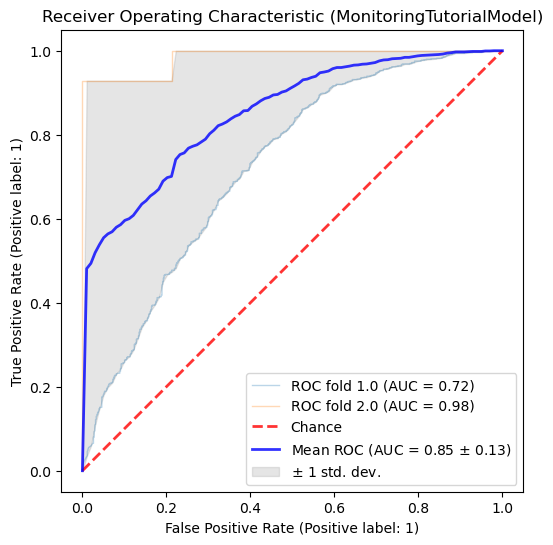

[<Figure size 600x600 with 1 Axes>]

<Figure size 640x480 with 0 Axes>

In [6]:
# plot the results for bootstrapping
from qsprpred.plotting.classification import ROCPlot

plot = ROCPlot([model])
plot.make(save=True, show=True, property_name=model.targetProperties[0].name,
          validation="cv")

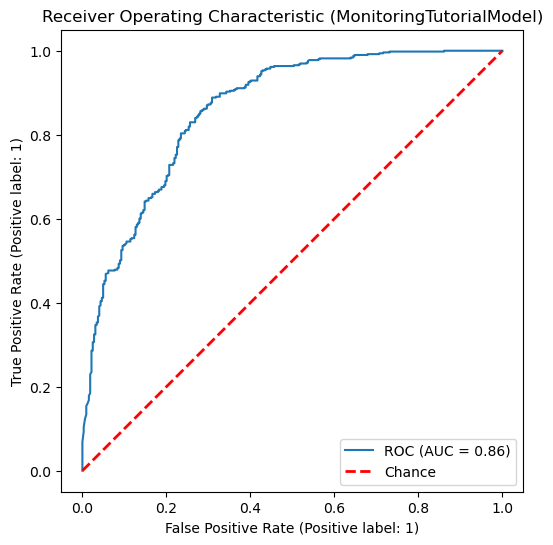

[<Figure size 600x600 with 1 Axes>]

<Figure size 640x480 with 0 Axes>

In [7]:
# plot test set results
plot.make(save=True, show=True, property_name=model.targetProperties[0].name,
          validation="ind")

In [19]:
from qsprpred.data import TemporalSplit

CrossValAssessor(
    scoring="roc_auc",
    split=TemporalSplit(timesplit=[ 2010, 2020], timeprop="Year")
)(model, dataset)

array([0.7233904 , 0.98469388])

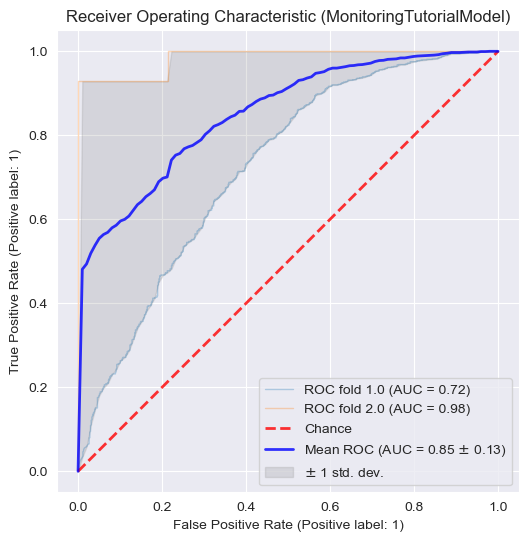

[<Figure size 600x600 with 1 Axes>]

<Figure size 640x480 with 0 Axes>

In [20]:
plot.make(save=True, show=True, property_name=model.targetProperties[0].name,
          validation="cv")

{'weight_decay': 0.00015, 'neuron_layers': [2048, 1024, 512], 'dropout_frac': 0.0, 'act_fun': <function selu at 0x14891a0c0>}